In [1]:
import random
import heapq
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import networkx as nx
from collections import defaultdict

In [2]:
# ---------- Common Graph Setup ----------
class UnionFind:
    def __init__(self, n):
        self.parent = list(range(n))

    def find(self, u):
        while self.parent[u] != u:
            self.parent[u] = self.parent[self.parent[u]]
            u = self.parent[u]
        return u

    def union(self, u, v):
        pu, pv = self.find(u), self.find(v)
        if pu != pv:
            self.parent[pu] = pv
            return True
        return False

In [3]:
# ---------- Load Graph from File ----------
edges = []
node_set = set()

with open("ENZYMES_g11.edges", "r") as file:
    for line in file:
        if line.strip():
            u, v = map(int, line.strip().split())
            edges.append((u, v, 1))  # assume weight = 1
            node_set.update([u, v])

In [4]:
# Remap node indices to 0-based
node_list = sorted(node_set)
node_to_index = {node: idx for idx, node in enumerate(node_list)}
edges_mapped = [(node_to_index[u], node_to_index[v], w) for u, v, w in edges]
n = len(node_list)

In [5]:
# ---------- Kruskal's Algorithm ----------
def kruskal(n, edges):
    edges.sort(key=lambda x: x[2])
    uf = UnionFind(n)
    mst = []
    total_weight = 0
    for u, v, w in edges:
        if uf.union(u, v):
            mst.append((u, v, w))
            total_weight += w
    return mst, total_weight

In [6]:
# ---------- Prim's Algorithm ----------
def prim(n, edges):
    adj = defaultdict(list)
    for u, v, w in edges:
        adj[u].append((w, v))
        adj[v].append((w, u))
    visited = [False] * n
    min_heap = [(0, 0)]
    total_weight = 0
    mst = []
    while min_heap:
        w, u = heapq.heappop(min_heap)
        if visited[u]:
            continue
        visited[u] = True
        total_weight += w
        for next_w, v in adj[u]:
            if not visited[v]:
                heapq.heappush(min_heap, (next_w, v))
                mst.append((u, v, next_w))
    return mst, total_weight

In [7]:
# ---------- Borůvka’s Algorithm ----------
def boruvka(n, edges):
    uf = UnionFind(n)
    mst = []
    total_weight = 0
    num_components = n
    while num_components > 1:
        cheapest = [-1] * n
        for i, (u, v, w) in enumerate(edges):
            set_u = uf.find(u)
            set_v = uf.find(v)
            if set_u != set_v:
                if cheapest[set_u] == -1 or edges[cheapest[set_u]][2] > w:
                    cheapest[set_u] = i
                if cheapest[set_v] == -1 or edges[cheapest[set_v]][2] > w:
                    cheapest[set_v] = i
        for i in range(n):
            if cheapest[i] != -1:
                u, v, w = edges[cheapest[i]]
                if uf.union(u, v):
                    mst.append((u, v, w))
                    total_weight += w
                    num_components -= 1
    return mst, total_weight

In [8]:
# ---------- Reverse Delete Algorithm ----------
def reverse_delete(n, edges):
    edges_sorted = sorted(edges, key=lambda x: -x[2])
    mst = edges[:]
    def is_connected(subgraph_edges):
        uf = UnionFind(n)
        for u, v, _ in subgraph_edges:
            uf.union(u, v)
        root = uf.find(0)
        return all(uf.find(i) == root for i in range(n))
    for u, v, w in edges_sorted:
        mst.remove((u, v, w))
        if not is_connected(mst):
            mst.append((u, v, w))
    total_weight = sum(w for _, _, w in mst)
    return mst, total_weight

In [9]:
# ---------- Karger’s Min-Cut Algorithm ----------
def karger_min_cut(n, edges, iterations=100):
    min_cut = float('inf')
    for _ in range(iterations):
        parent = list(range(n))
        e = edges[:]
        def find(u):
            while parent[u] != u:
                parent[u] = parent[parent[u]]
                u = parent[u]
            return u
        def union(u, v):
            pu, pv = find(u), find(v)
            if pu != pv:
                parent[pu] = pv
        vertices = n
        while vertices > 2:
            u, v, _ = random.choice(e)
            if find(u) != find(v):
                union(u, v)
                vertices -= 1
            e = [edge for edge in e if find(edge[0]) != find(edge[1])]
        cut = len([edge for edge in edges if find(edge[0]) != find(edge[1])])
        min_cut = min(min_cut, cut)
    return min_cut

In [10]:
# ---------- Run Algorithms ----------
kruskal_mst, kruskal_cost = kruskal(n, edges_mapped)
prim_mst, prim_cost = prim(n, edges_mapped)
boruvka_mst, boruvka_cost = boruvka(n, edges_mapped)
reverse_mst, reverse_cost = reverse_delete(n, edges_mapped)
karger_cut = karger_min_cut(n, edges_mapped)

# ---------- Print Results ----------
print("Kruskal’s MST:", kruskal_mst, "Total Weight:", kruskal_cost)
print("Prim’s MST:", prim_mst, "Total Weight:", prim_cost)
print("Borůvka’s MST:", boruvka_mst, "Total Weight:", boruvka_cost)
print("Reverse Delete MST:", reverse_mst, "Total Weight:", reverse_cost)
print("Karger’s Minimum Cut:", karger_cut)

Kruskal’s MST: [(1, 0, 1), (2, 0, 1), (3, 0, 1)] Total Weight: 3
Prim’s MST: [(0, 1, 1), (0, 2, 1), (0, 3, 1), (0, 1, 1), (0, 2, 1), (0, 3, 1), (1, 2, 1), (1, 3, 1), (1, 2, 1), (1, 3, 1), (2, 3, 1), (2, 3, 1)] Total Weight: 3
Borůvka’s MST: [(1, 0, 1), (2, 0, 1), (3, 0, 1)] Total Weight: 3
Reverse Delete MST: [(0, 3, 1), (1, 3, 1), (2, 3, 1)] Total Weight: 3
Karger’s Minimum Cut: 6


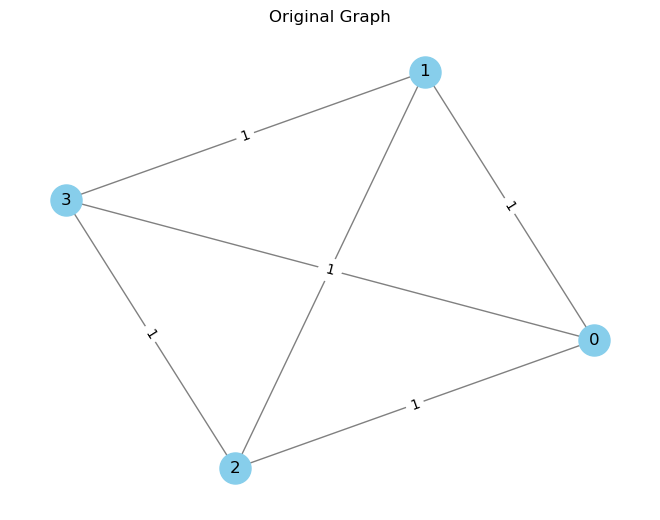

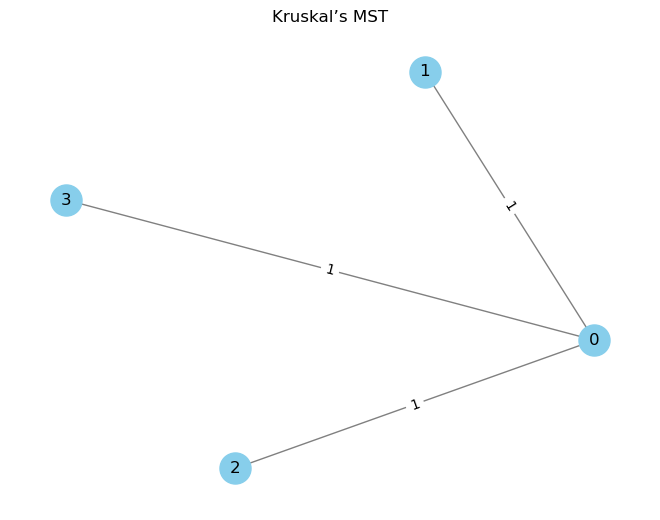

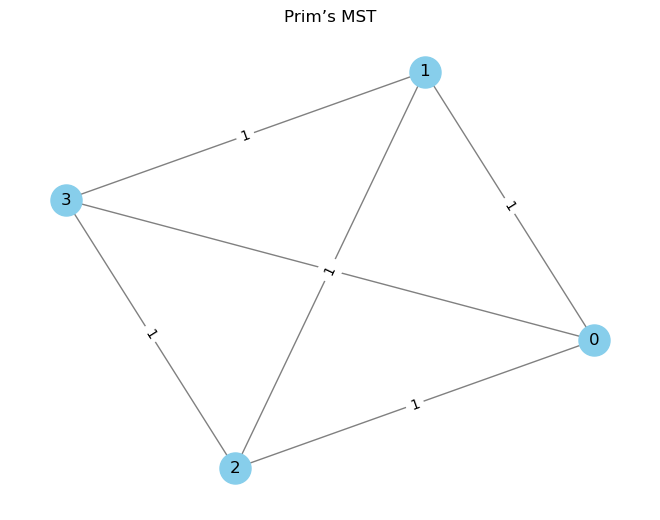

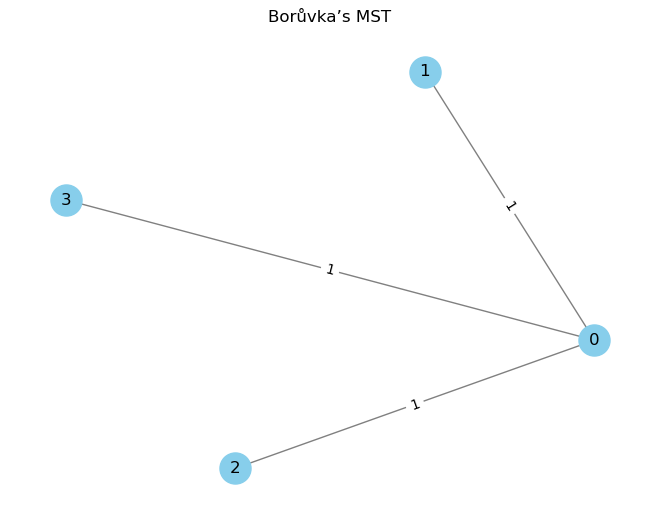

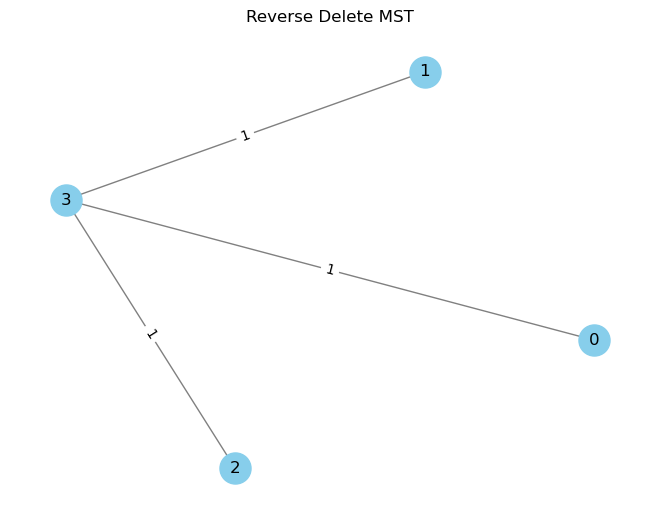

{1: array([0.35631846, 1.        ]),
 0: array([ 0.99392804, -0.35415491]),
 2: array([-0.35631846, -1.        ]),
 3: array([-0.99392804,  0.35415491])}

In [11]:
def visualize_graph(edge_list, title, pos=None):
    G = nx.Graph()
    for u, v, w in edge_list:
        G.add_edge(u, v, weight=w)
    if pos is None:
        pos = nx.spring_layout(G, seed=42)
    weights = nx.get_edge_attributes(G, 'weight')
    nx.draw(G, pos, with_labels=True, node_color='skyblue', edge_color='gray', node_size=500)
    nx.draw_networkx_edge_labels(G, pos, edge_labels=weights)
    plt.title(title)
    plt.show()
    return pos

# Visualize original graph
original_pos = visualize_graph(edges_mapped, "Original Graph")

# Visualize each MST using same layout
kruskal_mst, _ = kruskal(n, edges_mapped)
visualize_graph(kruskal_mst, "Kruskal’s MST", original_pos)

prim_mst, _ = prim(n, edges_mapped)
visualize_graph(prim_mst, "Prim’s MST", original_pos)

boruvka_mst, _ = boruvka(n, edges_mapped)
visualize_graph(boruvka_mst, "Borůvka’s MST", original_pos)

reverse_mst, _ = reverse_delete(n, edges_mapped)
visualize_graph(reverse_mst, "Reverse Delete MST", original_pos)
